In [4]:
# ============================================================
# 1) Instalar librerías necesarias
# ============================================================
!pip install pyxlsb openpyxl matplotlib -q

In [5]:
# ============================================================
# 2) Cargar y unir las hojas (CGR_PERSONAL_Y_COSTOS + Entidades)
#    con optimización de memoria
# ============================================================
import pandas as pd
import gc

ruta = "/content/Personal y Costo Planta 2025 06-04-2026-TOTAL_TOTAL1 (1).xlsb"

df = pd.read_excel(ruta, engine="pyxlsb", sheet_name="CGR_PERSONAL_Y_COSTOS")
entidades = pd.read_excel(ruta, engine="pyxlsb", sheet_name="Entidades")

df["CODENTIDAD"] = df["CODENTIDAD"].astype(str).str.strip()
entidades["BK_CHIP"] = entidades["BK_CHIP"].astype(str).str.strip()

df_completo = df.merge(
    entidades[["BK_CHIP", "DS_ENTIDAD", "DS_DEPARTAMENTO", "DS_CIUDAD", "DS_AMBITO_NOMBRE_CGR_CHIP"]],
    left_on="CODENTIDAD",
    right_on="BK_CHIP",
    how="left"
)

del df, entidades
gc.collect()

# Optimizar tipos: downcast numéricos, category para texto repetitivo
for col in df_completo.select_dtypes(include="number").columns:
    df_completo[col] = pd.to_numeric(df_completo[col], downcast="float")

for col in df_completo.select_dtypes(include="object").columns:
    if df_completo[col].nunique() / len(df_completo) < 0.5:
        df_completo[col] = df_completo[col].astype("category")

print(f"Shape final: {df_completo.shape}")
print(f"Registros sin match con catálogo de entidades: {df_completo['DS_ENTIDAD'].isna().sum()}")
print(f"Memoria usada: {df_completo.memory_usage(deep=True).sum() / 1e6:.2f} MB")

Shape final: (91130, 40)
Registros sin match con catálogo de entidades: 391
Memoria usada: 24.98 MB


In [6]:
# ============================================================
# 3) Ver todas las columnas finales disponibles
# ============================================================
for i, c in enumerate(df_completo.columns):
    tipo = "numérica" if pd.api.types.is_numeric_dtype(df_completo[c]) else "texto/categórica"
    nunique = df_completo[c].nunique()
    print(f"{i:2d}. {c}   ({tipo}, {nunique} valores únicos)")

 0. CODAMB   (texto/categórica, 4 valores únicos)
 1. CODENTIDAD   (texto/categórica, 3443 valores únicos)
 2. Unnamed: 2   (texto/categórica, 1 valores únicos)
 3. CONCEPTO   (numérica, 10 valores únicos)
 4. CONSECUTIVO   (numérica, 350 valores únicos)
 5. UNIDAD EJECUTORA ó DEPENDENCIA   (texto/categórica, 12 valores únicos)
 6. DENOMINACIÓN DEL CARGO   (texto/categórica, 27702 valores únicos)
 7. GRADO   (texto/categórica, 3009 valores únicos)
 8. CARGOS APROBADOS   (numérica, 603 valores únicos)
 9. CARGOS PROVISTOS   (numérica, 576 valores únicos)
10. TIPO DE VINCULACIÓN   (texto/categórica, 6 valores únicos)
11. ASIGNACIÓN BÁSICA ANUAL   (numérica, 71293 valores únicos)
12. GASTOS DE REPRESENTACIÓN ANUAL   (numérica, 2470 valores únicos)
13. PRIMA TÉCNICA ANUAL   (numérica, 3250 valores únicos)
14. PRIMA DE GESTIÓN ANUAL   (numérica, 408 valores únicos)
15. PRIMA DE LOCALIZACIÓN ANUAL   (numérica, 650 valores únicos)
16. PRIMA DE COORDINACIÓN ANUAL   (numérica, 2092 valores únic

In [7]:
# ============================================================
# 4) Función auxiliar: estimar cuántas combinaciones generaría
#    una consulta ANTES de correrla completa
# ============================================================
def ver_combinaciones(group_cols):
    for c in group_cols:
        if c not in df_completo.columns:
            raise ValueError(f"Columna no encontrada: {c}")
    n = df_completo[list(group_cols)].drop_duplicates().shape[0]
    print(f"La consulta {group_cols} generaría aproximadamente {n} combinaciones distintas.")
    return n

In [8]:
# ============================================================
# 5) Función principal de consulta (tabla + gráfico + Excel)
# ============================================================
import matplotlib.pyplot as plt
import textwrap

def consulta(group_cols, metrica="contar", top_n=20, nombre_archivo=None, max_combinaciones=5000):
    """
    group_cols: lista de columnas (1 a 5) para agrupar
    metrica: "contar" o nombre exacto de columna numérica a sumar
    top_n: cuántas filas graficar (None = todas, hasta max_combinaciones)
    max_combinaciones: tope de seguridad; si se supera, no se grafica (solo tabla + Excel)
    """
    if not (1 <= len(group_cols) <= 5):
        raise ValueError("Debes usar entre 1 y 5 columnas para agrupar")
    for c in group_cols:
        if c not in df_completo.columns:
            raise ValueError(f"Columna no encontrada: {c}")

    cols_necesarias = list(group_cols) + ([metrica] if metrica != "contar" else [])
    subset = df_completo[cols_necesarias].copy()

    for c in group_cols:
        subset[c] = subset[c].astype(str)

    if metrica == "contar":
        resultado = subset.groupby(group_cols, dropna=False, observed=True).size().reset_index(name="Cantidad")
        col_valor = "Cantidad"
    else:
        if metrica not in df_completo.columns:
            raise ValueError(f"Columna de métrica no encontrada: {metrica}")
        resultado = subset.groupby(group_cols, dropna=False, observed=True)[metrica].sum().reset_index()
        col_valor = metrica

    resultado = resultado.sort_values(col_valor, ascending=False).reset_index(drop=True)
    del subset
    gc.collect()

    print(f"\n=== Consulta: agrupado por {group_cols} | métrica: {metrica} ===")
    print(f"Total de combinaciones: {len(resultado)}")
    print(resultado.head(30).to_string(index=False))

    if len(resultado) > max_combinaciones:
        print(f"\n⚠️ Hay {len(resultado)} combinaciones, demasiadas para graficar de forma legible.")
        print("Se omite el gráfico, pero la tabla completa sí se guarda en Excel.")
    else:
        grafico_data = resultado.head(top_n) if top_n else resultado
        grafico_data = grafico_data.copy()

        if len(group_cols) > 1:
            etiqueta = grafico_data[group_cols[0]].astype(str)
            for c in group_cols[1:]:
                etiqueta = etiqueta + " | " + grafico_data[c].astype(str)
        else:
            etiqueta = grafico_data[group_cols[0]].astype(str)

        etiqueta = etiqueta.apply(lambda x: "\n".join(textwrap.wrap(x, 40)))

        usar_horizontal = len(grafico_data) > 8
        plt.figure(figsize=(10, max(4, len(grafico_data) * 0.35)) if usar_horizontal else (10, 6))
        if usar_horizontal:
            plt.barh(etiqueta[::-1], grafico_data[col_valor][::-1])
            plt.xlabel(col_valor)
        else:
            plt.bar(etiqueta, grafico_data[col_valor])
            plt.ylabel(col_valor)
            plt.xticks(rotation=45, ha="right")

        plt.title(f"{col_valor} por {' + '.join(group_cols)}")
        plt.tight_layout()
        plt.show()
        plt.close()

    if nombre_archivo is None:
        nombre_archivo = "consulta_" + "_".join(group_cols).replace(" ", "_")[:50]
    ruta_salida = f"/content/{nombre_archivo}.xlsx"
    resultado.to_excel(ruta_salida, index=False)
    print(f"\nExcel guardado en: {ruta_salida}")

    del resultado
    gc.collect()

    return pd.read_excel(ruta_salida)


=== Consulta: agrupado por ['DS_DEPARTAMENTO'] | métrica: contar ===
Total de combinaciones: 34
                   DS_DEPARTAMENTO  Cantidad
                  DISTRITO CAPITAL     13261
         DEPARTAMENTO DE ANTIOQUIA     12299
      DEPARTAMENTO DE CUNDINAMARCA      5616
   DEPARTAMENTO DE VALLE DEL CAUCA      5165
            DEPARTAMENTO DE NARIÑO      4681
            DEPARTAMENTO DE BOYACA      4469
         DEPARTAMENTO DE SANTANDER      3984
            DEPARTAMENTO DE TOLIMA      3397
           DEPARTAMENTO DE BOLIVAR      3226
         DEPARTAMENTO DE ATLANTICO      3009
             DEPARTAMENTO DE CAUCA      2779
            DEPARTAMENTO DE CALDAS      2602
             DEPARTAMENTO DE CESAR      2292
             DEPARTAMENTO DE HUILA      2262
DEPARTAMENTO DE NORTE DE SANTANDER      2122
           DEPARTAMENTO DE CORDOBA      2052
           DEPARTAMENTO DE GUAJIRA      1932
         DEPARTAMENTO DE RISARALDA      1834
         DEPARTAMENTO DE MAGDALENA      1826
   

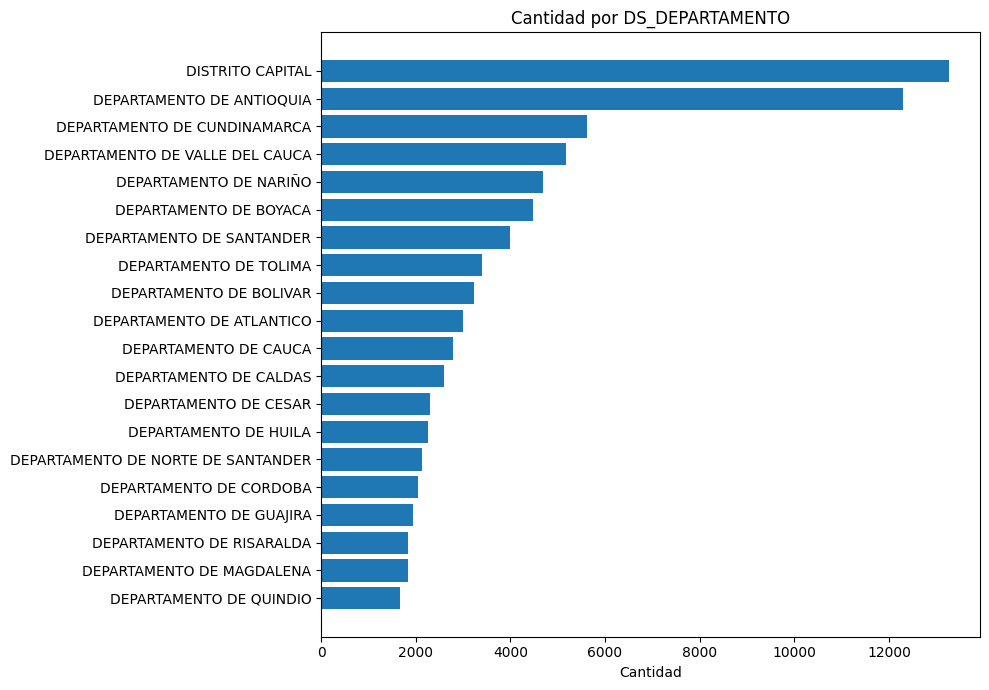


Excel guardado en: /content/consulta_DS_DEPARTAMENTO.xlsx


In [9]:
# ============================================================
# 6) EJEMPLOS DE USO
# ============================================================

# Antes de una consulta con varias columnas, puedes verificar el tamaño:
# ver_combinaciones(["DS_DEPARTAMENTO", "DENOMINACIÓN DEL CARGO"])

# Ejemplo 1: conteo de cargos por departamento
res1 = consulta(["DS_DEPARTAMENTO"], metrica="contar")


=== Consulta: agrupado por ['DS_DEPARTAMENTO', 'TIPO DE VINCULACIÓN'] | métrica: contar ===
Total de combinaciones: 201
                   DS_DEPARTAMENTO TIPO DE VINCULACIÓN  Cantidad
                  DISTRITO CAPITAL                  V1      5139
         DEPARTAMENTO DE ANTIOQUIA                  V1      4384
                  DISTRITO CAPITAL                  V6      3243
                  DISTRITO CAPITAL                  V3      3220
   DEPARTAMENTO DE VALLE DEL CAUCA                  V1      2467
      DEPARTAMENTO DE CUNDINAMARCA                  V1      2309
         DEPARTAMENTO DE ANTIOQUIA                  V3      2180
         DEPARTAMENTO DE ANTIOQUIA                  V5      1952
            DEPARTAMENTO DE NARIÑO                  V1      1805
         DEPARTAMENTO DE ANTIOQUIA                  V6      1802
            DEPARTAMENTO DE BOYACA                  V1      1783
         DEPARTAMENTO DE SANTANDER                  V1      1535
           DEPARTAMENTO DE BOLIVAR

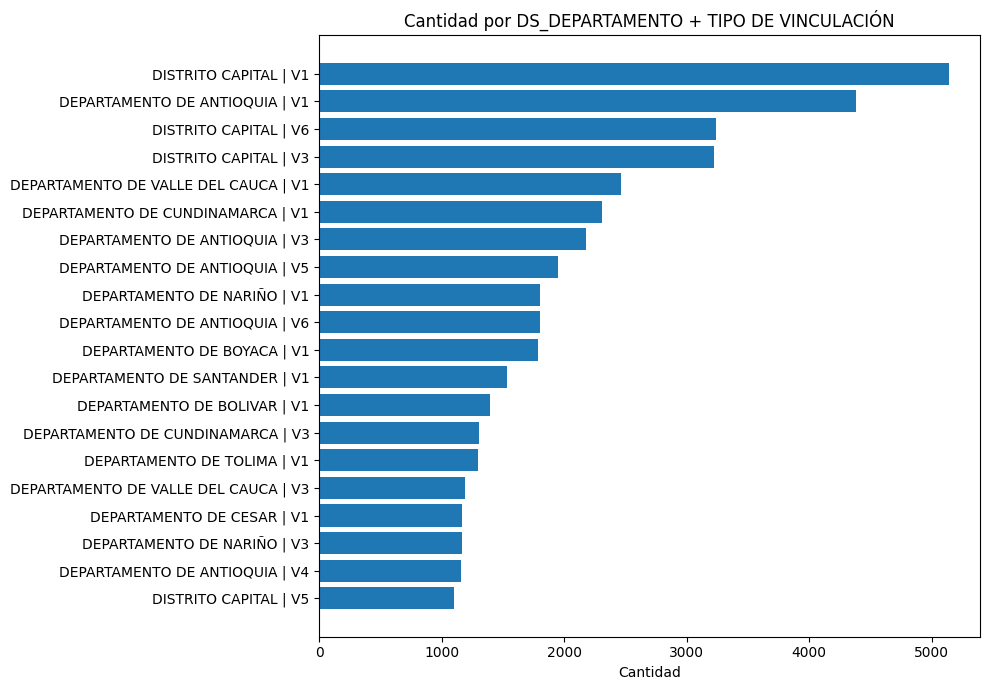


Excel guardado en: /content/consulta_DS_DEPARTAMENTO_TIPO_DE_VINCULACIÓN.xlsx


In [10]:
# Ejemplo 2: tipo de vinculación dentro de un departamento
res2 = consulta(["DS_DEPARTAMENTO", "TIPO DE VINCULACIÓN"], metrica="contar")


=== Consulta: agrupado por ['DS_DEPARTAMENTO', 'UNIDAD EJECUTORA ó DEPENDENCIA'] | métrica: ASIGNACIÓN BÁSICA ANUAL ===
Total de combinaciones: 259
                   DS_DEPARTAMENTO UNIDAD EJECUTORA ó DEPENDENCIA  ASIGNACIÓN BÁSICA ANUAL
                  DISTRITO CAPITAL                            nan             3.088608e+13
         DEPARTAMENTO DE ANTIOQUIA                            nan             2.870666e+12
         DEPARTAMENTO DE ANTIOQUIA                            D14             2.208689e+12
             DEPARTAMENTO DE CESAR                            nan             1.235984e+12
   DEPARTAMENTO DE VALLE DEL CAUCA                            D14             1.166720e+12
            DEPARTAMENTO DE NARIÑO                            D14             1.069585e+12
         DEPARTAMENTO DE ANTIOQUIA                            D07             8.865531e+11
   DEPARTAMENTO DE VALLE DEL CAUCA                            nan             8.068090e+11
         DEPARTAMENTO DE SANTAND

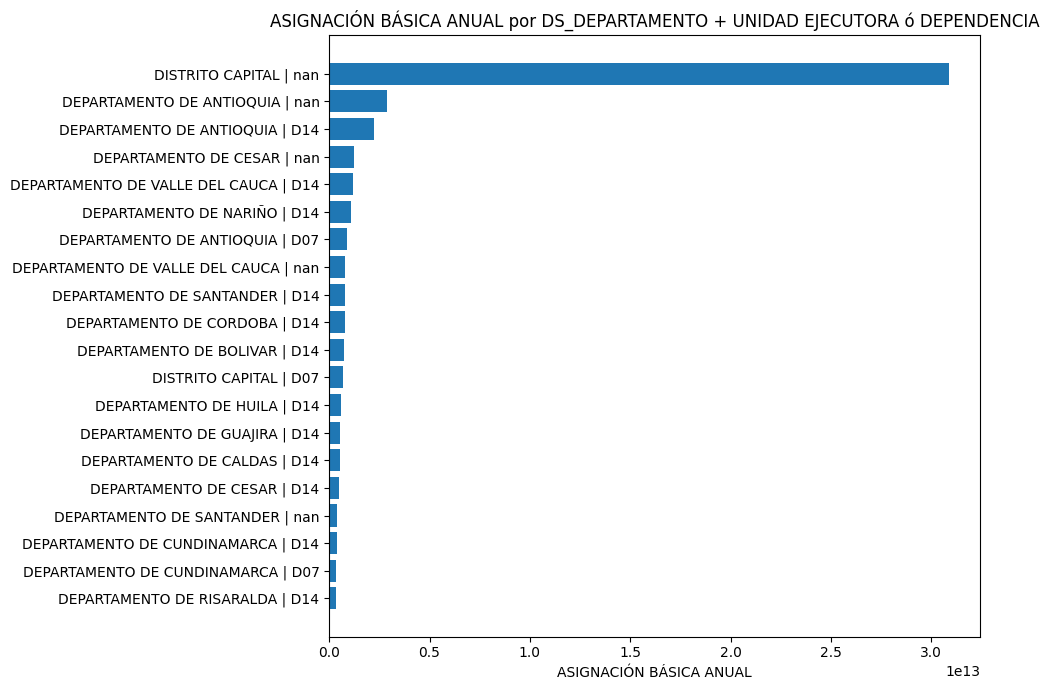


Excel guardado en: /content/consulta_DS_DEPARTAMENTO_UNIDAD_EJECUTORA_ó_DEPENDENCIA.xlsx


In [11]:
# Ejemplo 3: suma de asignación básica anual por dependencia
res3 = consulta(
    ["DS_DEPARTAMENTO", "UNIDAD EJECUTORA ó DEPENDENCIA"],
    metrica="ASIGNACIÓN BÁSICA ANUAL"
)

In [12]:
# Ejemplo 4: consulta con varias variables (revisa combinaciones primero)
ver_combinaciones(["DS_DEPARTAMENTO", "DS_CIUDAD", "TIPO DE VINCULACIÓN", "DENOMINACIÓN DEL CARGO", "GRADO"])
# Si el número es razonable (cientos, no decenas de miles), continúa:
res4 = consulta(
    ["DS_DEPARTAMENTO", "DS_CIUDAD", "TIPO DE VINCULACIÓN", "DENOMINACIÓN DEL CARGO", "GRADO"],
    metrica="contar",
    top_n=15
)

La consulta ['DS_DEPARTAMENTO', 'DS_CIUDAD', 'TIPO DE VINCULACIÓN', 'DENOMINACIÓN DEL CARGO', 'GRADO'] generaría aproximadamente 74525 combinaciones distintas.

=== Consulta: agrupado por ['DS_DEPARTAMENTO', 'DS_CIUDAD', 'TIPO DE VINCULACIÓN', 'DENOMINACIÓN DEL CARGO', 'GRADO'] | métrica: contar ===
Total de combinaciones: 74525
                   DS_DEPARTAMENTO                                                DS_CIUDAD TIPO DE VINCULACIÓN                   DENOMINACIÓN DEL CARGO GRADO  Cantidad
DEPARTAMENTO DE NORTE DE SANTANDER                                       SAN JOSE DE CUCUTA                  V1                                  DOCENTE     0       179
         DEPARTAMENTO DE ANTIOQUIA                                                    TURBO                  V4         AUXILIAR AREA -SALUD ENFERMERIA      8        93
           DEPARTAMENTO DE QUINDIO                                                  ARMENIA                  V1 DOCENTE TITULAR TC                           1    